## Time series Analysis on Avocado dataset

Group E

In [159]:
import pandas as pd
import janitor
from  matplotlib import pyplot as plt
import seaborn as sns
from plotnine import *

In [160]:
avocado_ts = pd.read_csv("avocado.csv")
avocado_ts = avocado_ts.clean_names()

avocad = avocado_ts.drop(columns = ["unnamed_0"])
avocad

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2/4/2018,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,1/28/2018,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,1/21/2018,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,1/14/2018,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


In [161]:
avocad["date"] = pd.to_datetime(avocad["date"])  #date column converted to datetime format

#to extract month and year
avocad ["month"] = avocad ["date"].dt.month
avocad ["year"] = avocad ["date"].dt.year

avocad

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico,2
18245,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico,1
18246,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico,1
18247,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico,1


## set date as index 

In [162]:
avocad1 = avocad.set_index("date")

avocad1

,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
date,,,,,,,,,,,,,
2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico,2
2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico,1
2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico,1


In [163]:
# Filtering
#We pick one type and one region to get a "pure" signal: 
filtered_avocado = avocad1[(avocad1['type'] == 'organic') & (avocad1['region'] == 'TotalUS')]

filtered_avocado

,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
date,,,,,,,,,,,,,
2015-12-27,1.52,549787.59,89709.92,206198.62,5836.04,248043.01,142262.93,105780.08,0.00,organic,2015,TotalUS,12
2015-12-20,1.53,531478.24,93849.30,205909.13,8733.11,222986.70,130418.73,92567.97,0.00,organic,2015,TotalUS,12
2015-12-13,1.43,624300.31,91837.92,222314.60,11645.54,298502.25,149767.80,148734.45,0.00,organic,2015,TotalUS,12
2015-12-06,1.52,514112.96,90203.21,212582.74,4066.09,207260.92,108684.49,98576.43,0.00,organic,2015,TotalUS,12
2015-11-29,1.50,507830.81,79215.51,208733.32,3749.48,216132.50,91658.24,124474.26,0.00,organic,2015,TotalUS,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-02-04,1.53,1384683.41,117922.52,287724.61,1703.52,977084.84,774695.74,201878.69,510.41,organic,2018,TotalUS,2
2018-01-28,1.61,1336979.09,118616.17,280080.34,1270.61,936859.49,796104.27,140652.84,102.38,organic,2018,TotalUS,1
2018-01-21,1.63,1283987.65,108705.28,259172.13,1490.02,914409.26,710654.40,203526.59,228.27,organic,2018,TotalUS,1


## Resampling

In [164]:
#Resample to make the series equally spaced
avoc_filtered_month = filtered_avocado['averageprice'].resample('ME').agg(["mean"])
avoc_filtered_month


,mean
date,
2015-01-31,1.4575
2015-02-28,1.4825
2015-03-31,1.4960
2015-04-30,1.5500
2015-05-31,1.4920
2015-06-30,1.6625
2015-07-31,1.0000
2015-08-31,1.4260
2015-09-30,1.7750


In [165]:
avoc_filtered_month.isnull().sum() #to check for any missing value

mean    0
dtype: int64

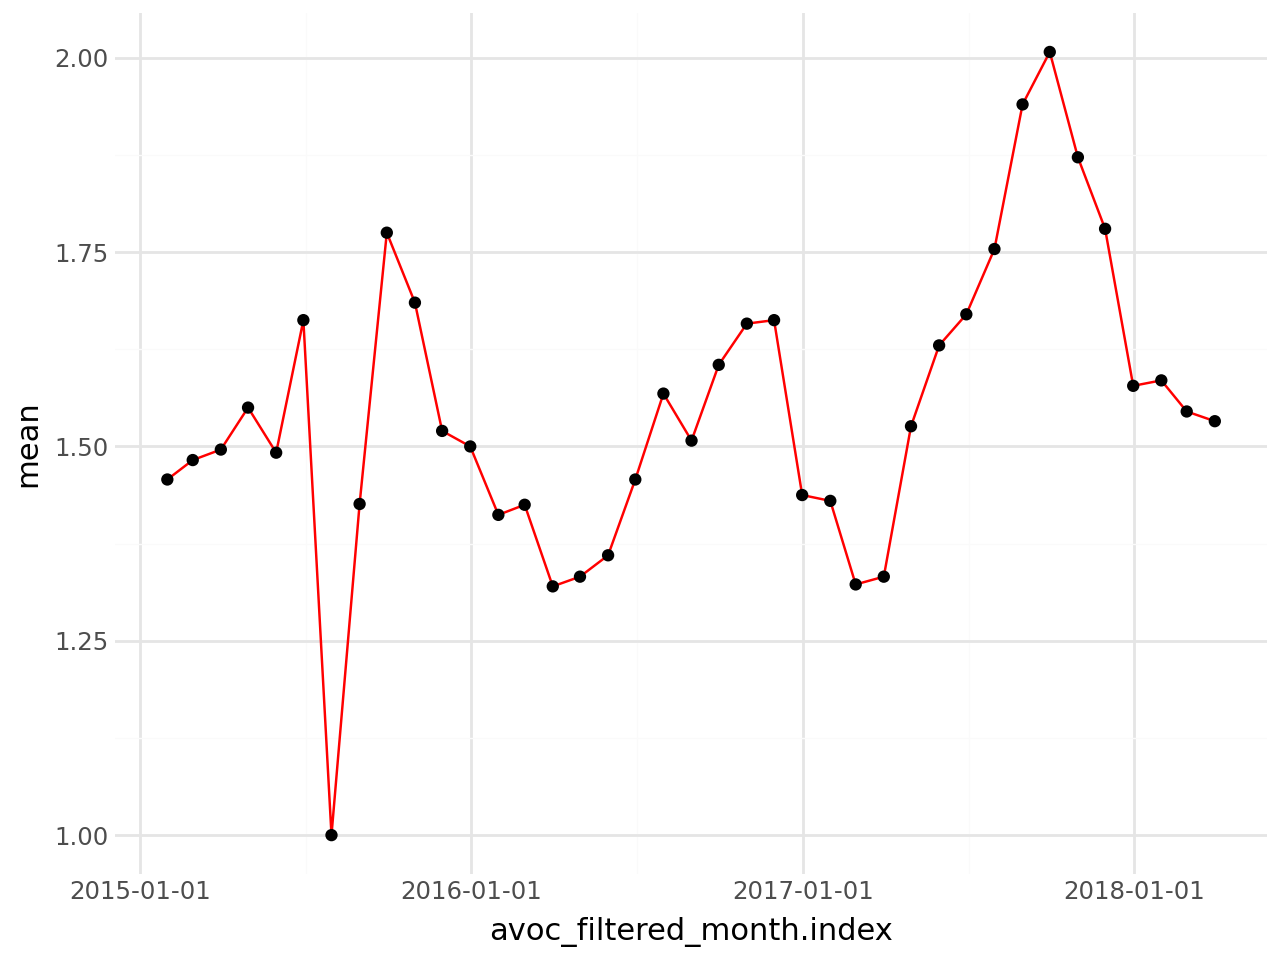

In [166]:
(ggplot(avoc_filtered_month, aes("avoc_filtered_month.index", "mean")) 
+ geom_line(color = "red")
+ geom_point()
+ scale_x_datetime(date_breaks = "12 months", limits = ["2015-01-31", "2018-03-31"]) 
+ theme_minimal()
)

This plot follows a pattern. There was a massive drop in June but it started rising July through September in 2015. 

Each year, the price increases from July to September and starts dropping from September to December. 

In 2017, the average price was risng March, peaked around September-October, and then dropped again in November-December.

Therefore, we can say there are variances and there is seasonality in this data.

## Linearity


In [193]:
avoc_filtered_month ["shift"] = avoc_filtered_month["mean"].shift(1)

avoc_filtered_month

,date,mean,shift
0,2015-01-31,1.4575,NaN
1,2015-02-28,1.4825,1.4575
2,2015-03-31,1.4960,1.4825
3,2015-04-30,1.5500,1.4960
4,2015-05-31,1.4920,1.5500
5,2015-06-30,1.6625,1.4920
6,2015-07-31,1.0000,1.6625
7,2015-08-31,1.4260,1.0000
8,2015-09-30,1.7750,1.4260
9,2015-10-31,1.6850,1.7750


C:\Users\Dell\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
C:\Users\Dell\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


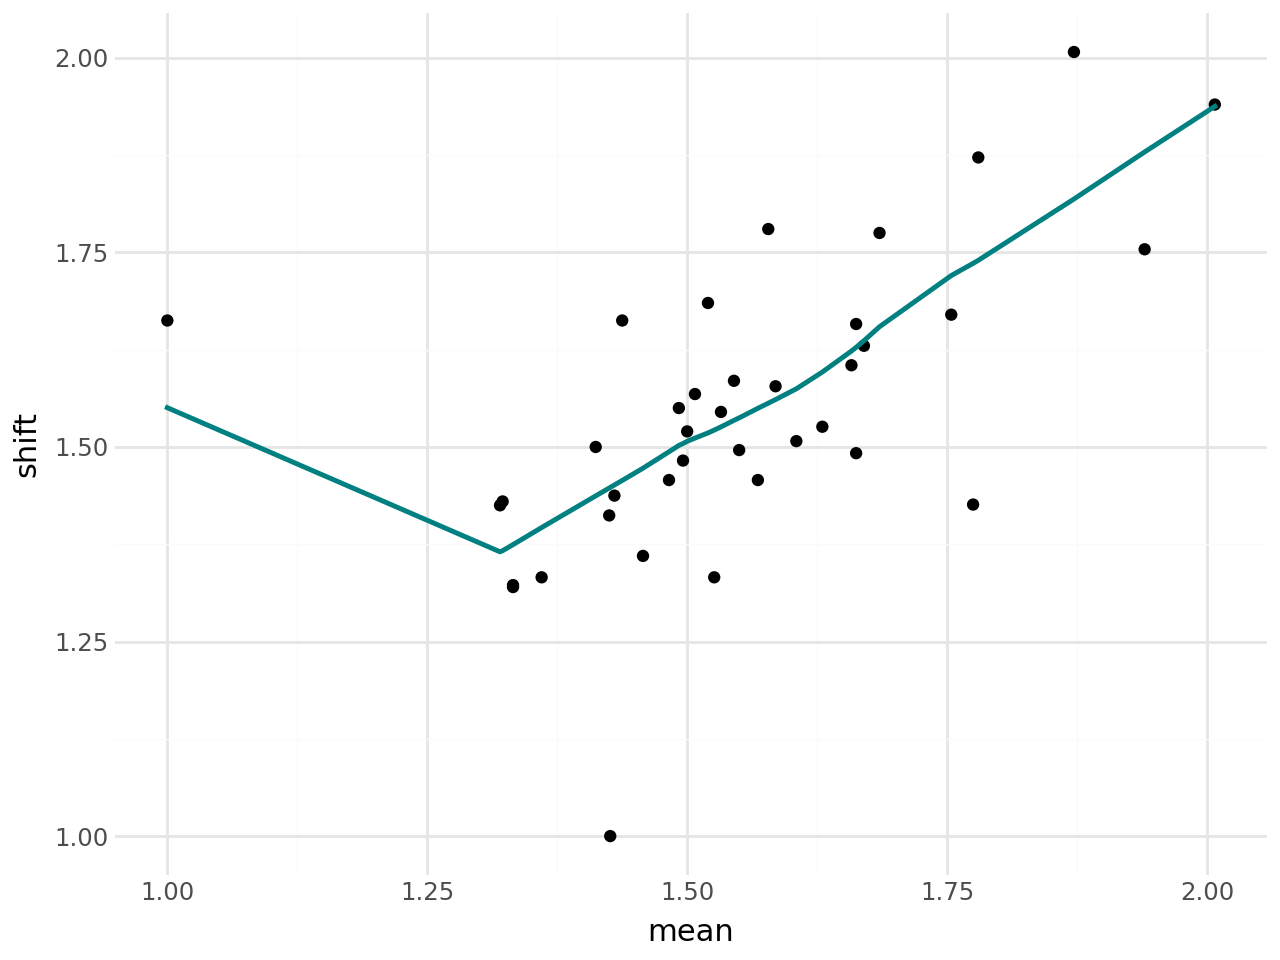

In [194]:
(ggplot(avoc_filtered_month, aes("mean", "shift"))
+ geom_point()
+ geom_smooth(linetype = "-", color = "teal") 
+ theme_minimal())

This plot show there is correlation between the previous month price and present month's price

## Stationarity

In [169]:
from statsmodels.tsa.stattools import adfuller

In [170]:
avoc_month = avoc_filtered_month[["mean"]]

avoc_month.head()

,mean
date,
2015-01-31,1.4575
2015-02-28,1.4825
2015-03-31,1.4960
2015-04-30,1.5500
2015-05-31,1.4920


In [171]:
avocado_adfuller = adfuller(avoc_month)

avocado_adfuller

(np.float64(-2.4720889458571365),
 np.float64(0.12241390591399126),
 2,
 36,
 {'1%': np.float64(-3.626651907578875),
  '5%': np.float64(-2.9459512825788754),
  '10%': np.float64(-2.6116707716049383)},
 np.float64(-50.5920960563768))

In [172]:
pd.Series(avocado_adfuller[0:5], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used', "Critical Value"])

Test Statistic                                                         -2.472089
p-value                                                                 0.122414
#Lags Used                                                                     2
Number of Observations Used                                                   36
Critical Value                 {'1%': -3.626651907578875, '5%': -2.9459512825...
dtype: object

The p-value is 0.12 which is > 0.05; therefore, we fail to reject the null hypothesis, and the data is not stationary

## Analyze trend and seasonality (Decomposition)

In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

In [173]:
# we have to do differencing because the data is not stationary

avocado_diff = avoc_filtered_month['mean'].diff().dropna()

# Check stationarity again with ADF
from statsmodels.tsa.stattools import adfuller
avocado_adfuller1 = adfuller(avocado_diff)

pd.Series(avocado_adfuller1[0:5], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used', "Critical Value"])

Test Statistic                                                         -7.035413
p-value                                                                      0.0
#Lags Used                                                                     0
Number of Observations Used                                                   37
Critical Value                 {'1%': -3.6209175221605827, '5%': -2.943539461...
dtype: object

## Autocorrelation plot

In [174]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

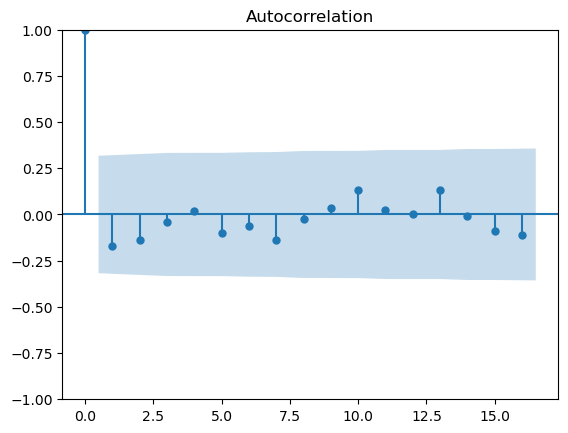

In [175]:
plot_acf(avocado_diff)

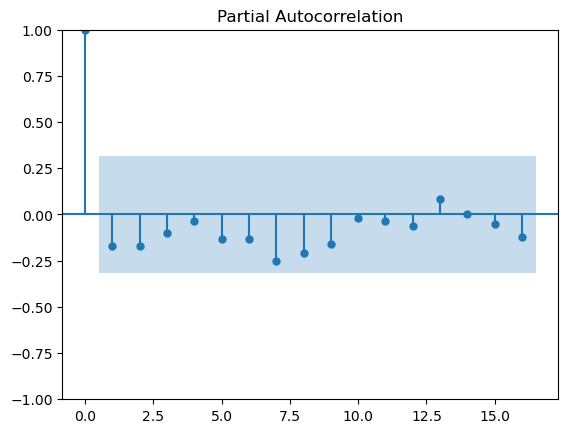

In [176]:
plot_pacf(avocado_diff)

The plot is showing no lag because we have done differencing. In the model, we will dwell on differencing

SARIMAX model will be used to handle the seasonal_order parameter.

## Set up Exogenous Variable ($X$)

In [177]:
# 1. Resample Volume to Monthly (matching your price 'mean' data)
avoc_vol = filtered_avocado['total_volume'].resample('ME').agg(["mean"])
avoc_vol.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 39 entries, 2015-01-31 to 2018-03-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mean    39 non-null     float64
dtypes: float64(1)
memory usage: 624.0 bytes


In [178]:
avoc_vol.isna().sum()

mean    0
dtype: int64

## Training and building the model using SARIMA

In [179]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [180]:
avoc_model = SARIMAX(avoc_filtered_month['mean'], # dependent variable (y)
                exog=avoc_vol, # the predictor (volume)
                order=(0, 1, 0),  # differencing, d=1, handles the stationarity
                seasonal_order=(1, 0, 0, 12), #the model looks for patterns that repeat every 12 months
                enforce_stationarity=False,
                enforce_invertibility=False) # Handles the yearly peaks

#to fits the model to our dataset
avoc_sarima = avoc_model.fit(maxiter=500, method='powell')

print(avoc_sarima.summary())

Optimization terminated successfully.
         Current function value: -0.655781
         Iterations: 2
         Function evaluations: 69
                                     SARIMAX Results                                      
Dep. Variable:                               mean   No. Observations:                   39
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood                  25.575
Date:                            Thu, 16 Apr 2026   AIC                            -45.151
Time:                                    21:34:51   BIC                            -41.377
Sample:                                01-31-2015   HQIC                           -44.064
                                     - 03-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

With a P-value of 0.033, the total volume is a statistically significant predictor of avocado prices in Albany.

Coefficient (-3.769e-07) confirms the inverse relationship, so as volume (supply) goes up, the average price goes down.

Prob(Q) (0.35) should be above 0.05 which means they are independent  and are not autocorrelated. Heteroskedasticity (H) (3.28) so we fail to reject the null hypothesis 

Prob(JB) (0.11) is above 0.05. This confirms the errors are Normally Distributed

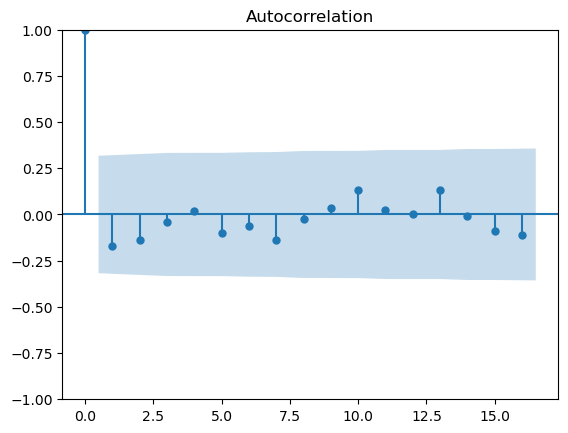

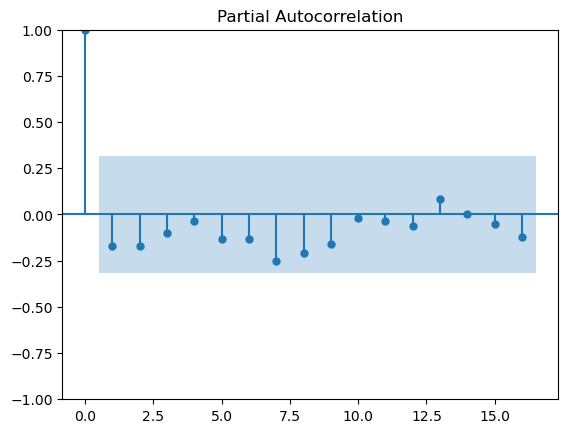

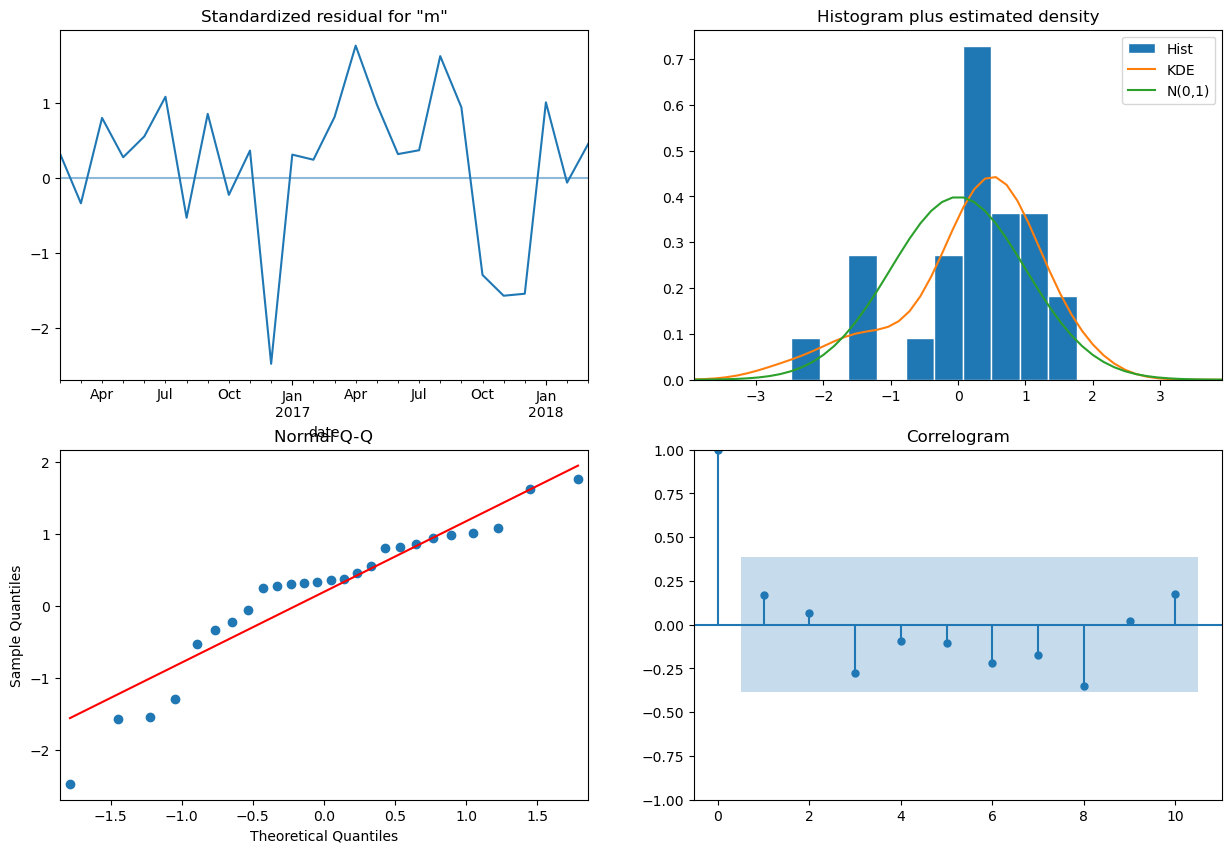

In [181]:
## Evaluating the residual

results.plot_diagnostics(figsize=(15, 10))
plt.show()

Standardized Residuals plot shows the "errors" (the difference between predicted and actual prices) over time

Histogram plus Estimated Density plot checks if the errors are normally distributed. From the plot, the model errors are not biased and they are random and balanced.

Normal Q-Q plot:  the dots lie mostly along the line, then the residuals are normally distributed. 



In [182]:
avocado_predict = results.predict(avoc_filtered_month.index[0],
                                 end=avoc_filtered_month.index[-1],
                                 dynamic = False, exog=avoc_vol)
avocado_predict = avocado_predict.reset_index()


In [183]:
avoc_filtered_month = avoc_filtered_month.reset_index()

avocado_predict ["actual_price"] = avoc_filtered_month["mean"]
avocado_predict

,date,predicted_mean,actual_price
0,2015-01-31,-0.240439,1.4575
1,2015-02-28,1.437764,1.4825
2,2015-03-31,1.471312,1.4960
3,2015-04-30,1.482822,1.5500
4,2015-05-31,1.535488,1.4920
5,2015-06-30,1.547527,1.6625
6,2015-07-31,1.669698,1.0000
7,2015-08-31,0.996628,1.4260
8,2015-09-30,1.461913,1.7750
9,2015-10-31,1.775637,1.6850


In [184]:
avocado_predict = avocado_predict.iloc[1:]


avocado_predict.head()

,date,predicted_mean,actual_price
1,2015-02-28,1.437764,1.4825
2,2015-03-31,1.471312,1.4960
3,2015-04-30,1.482822,1.5500
4,2015-05-31,1.535488,1.4920
5,2015-06-30,1.547527,1.6625


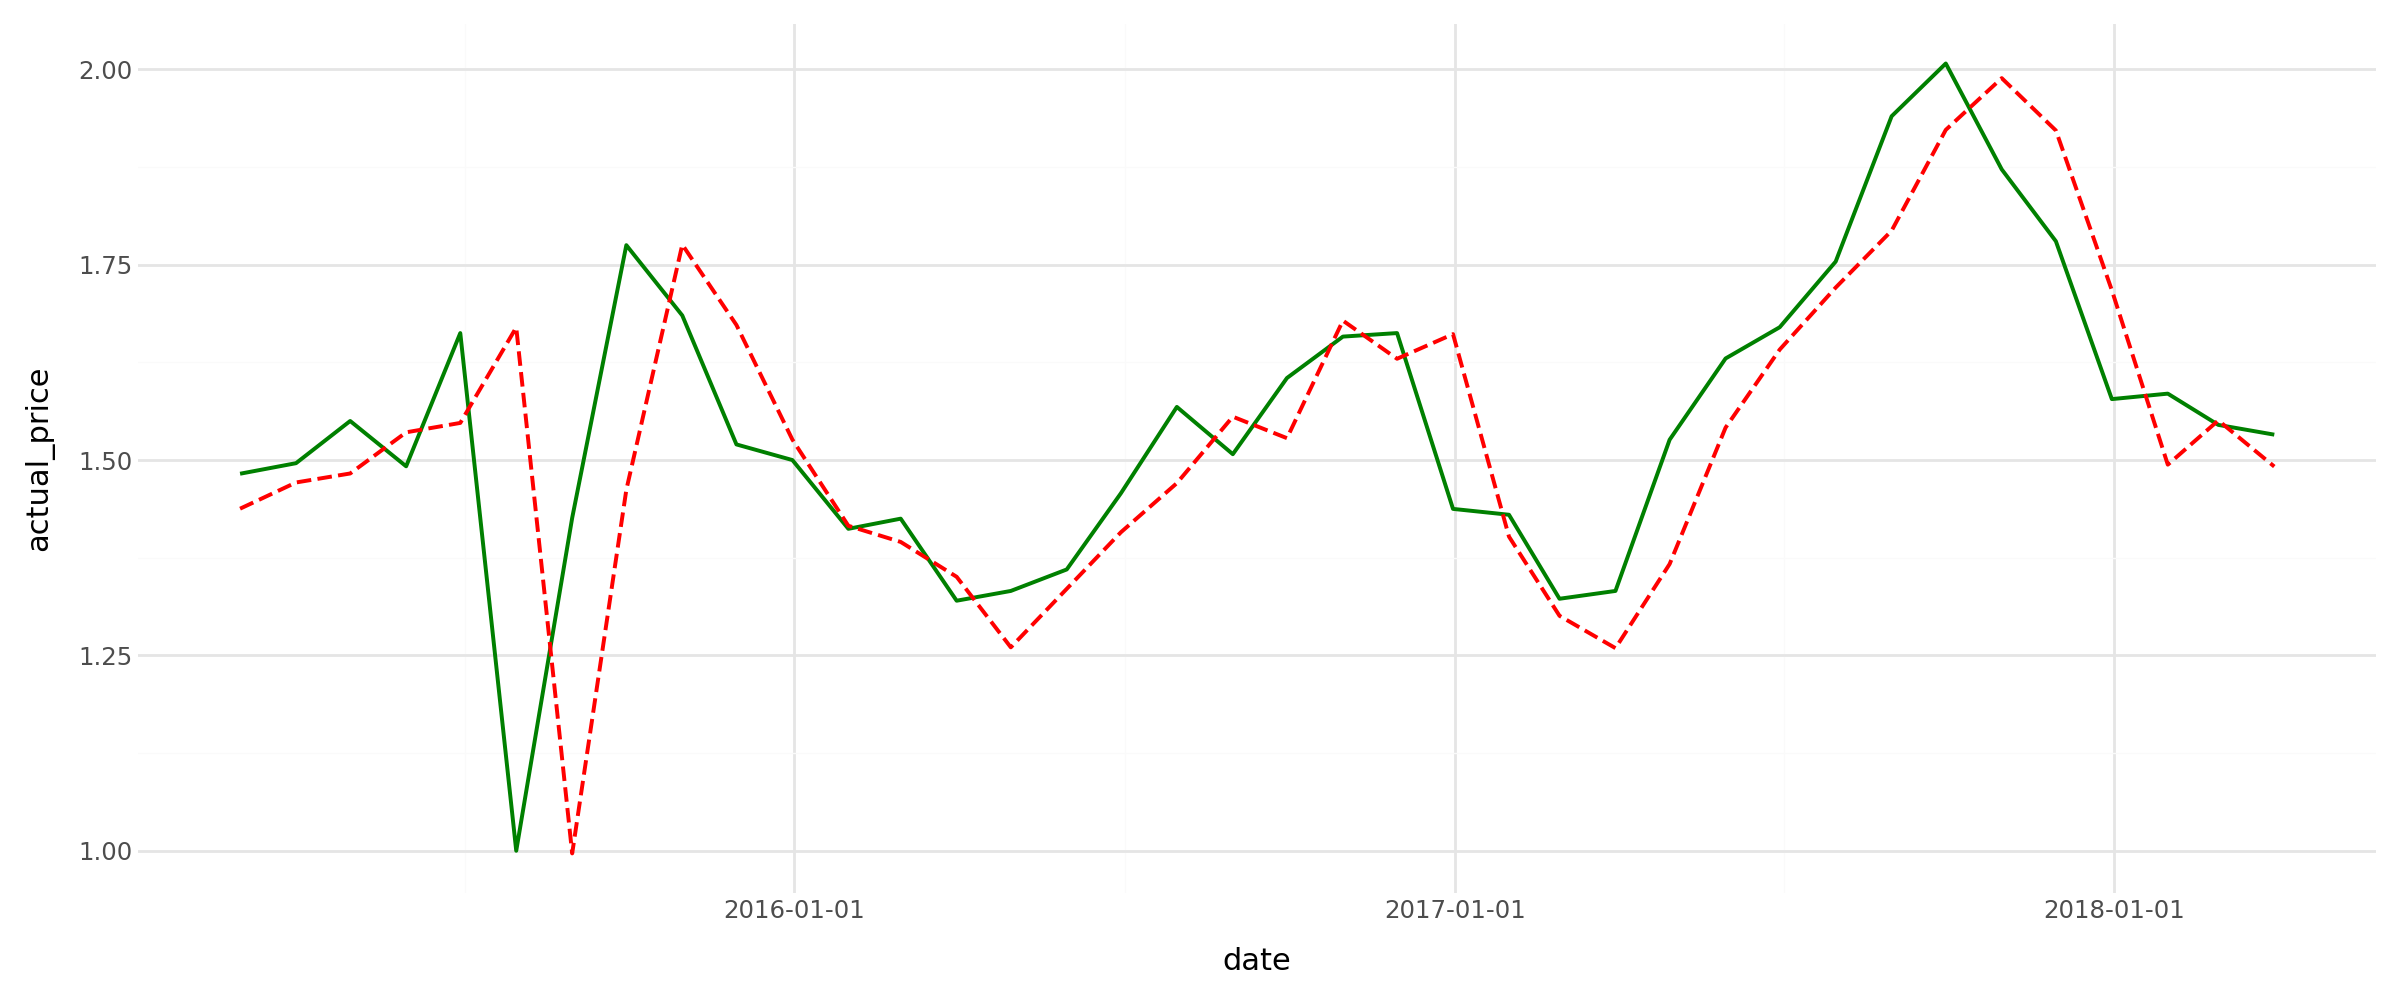

In [187]:
(ggplot(avocado_predict, aes("date", "actual_price"))
+ geom_line(color = "green", size = 0.8)
+ geom_line(avocado_predict, aes("date", "predicted_mean"), color = "red", size = 0.8, linetype = "--") 
+ theme_minimal()
+ theme(figure_size = (12, 5))
)


In [188]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [190]:
mse = mean_squared_error(avocado_predict["actual_price"], avocado_predict["predicted_mean"])
rmse = np.sqrt(mse)
rmse

np.float64(0.1620792892784015)

In [191]:
mae = mean_absolute_error(avocado_predict["actual_price"], avocado_predict["predicted_mean"])
mae

0.10228112278788803

In [192]:
#here is why I did not use the ARIMA model guys :
# the trend is wavy and the residual has pattern which is not supposed to be

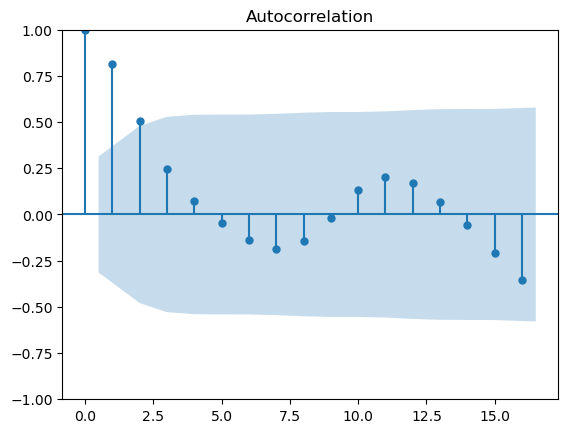

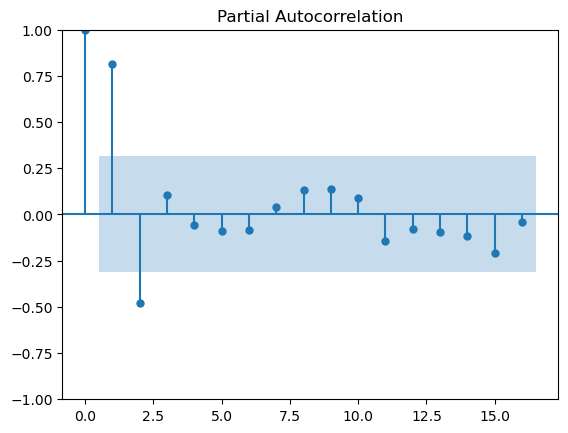

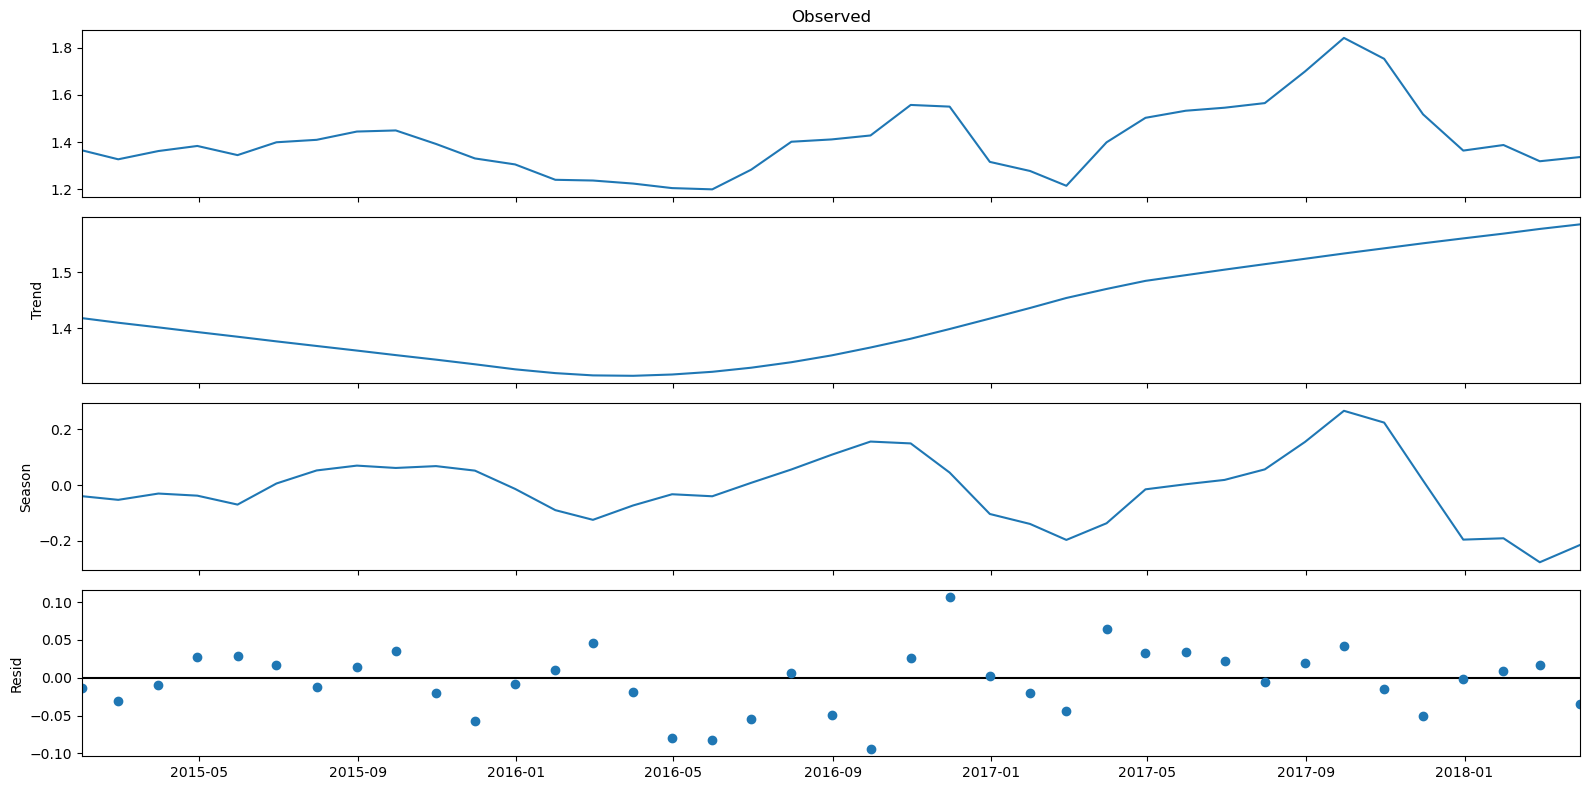

In [51]:
avoc_stl = STL(avoc1)
avoc_res = avoc_stl.fit()
result = avoc_res.plot()

result.set_size_inches(16, 8)

result.tight_layout()

plt.show()

The trend plot is kind of wavy then the trend is non-linear , there is seasonality then there is residual (noises), which has pattern. It is better residuals are scatter all over with no pattern